In [1]:
%cd ..

c:\Users\ntuankiet1\Desktop\Workspace\VLSP_2025_SIGMA


In [5]:
from src.services.detection_service.detector_models import RoboflowDetector
from src.services.detection_service.detector_pipeline import DetectorPipeline

pipeline = DetectorPipeline(
    detector=RoboflowDetector()
)

In [7]:
import json
from pathlib import Path

DATA_DIR = Path("./data")
input_path = DATA_DIR / "processed/law_db/images"
output_path = DATA_DIR / "traffic_sign_db" / "traffic_sign_descriptions.json"

with open("./data/traffic_sign_db/traffic_sign_descriptions.json") as f:
    traffic_sign_descriptions = json.load(f)

traffic_sign_descriptions[0]

{'law_id': 'QCVN 41:2024/BGTVT',
 'law_title': 'QUY CHUẨN KỸ THUẬT QUỐC GIA VỀ BÁO HIỆU ĐƯỜNG BỘ',
 'article_id': 'B.1',
 'article_title': 'B.1 Biển số P.101 “Đường cấm”',
 'text': 'a) Để báo đường cấm các loại phương tiện đi lại cả hai hướng, trừ các xe được ưu tiên theo quy định, đặt biển số P.101 “Đường cấm”.\nb) Nếu đường cấm vì lý do đường, cầu bị tắc thì biển cấm đặt ở giữa phần xe chạy kèm theo có hàng rào chắn ngang trước phần xe chạy như quy định ở Điều 77, các xe được ưu tiên cũng không được phép đi vào.\nc) Nếu đường cấm cả người đi bộ, đặt thêm biển số P.112 “Cấm người đi bộ” (ở trong khu đông dân cư) hoặc kéo dài hàng rào chắn ngang suốt cả nền đường (ở ngoài khu đông dân cư).\nd) Nếu đường cấm vì những lý do khác nhưng cầu, đường vẫn sử dụng được thì biển đặt ở giữa đường nhưng không đặt hàng rào chắn.\ne) Nếu phần xe chạy quá hẹp, biển đặt ở giữa phần xe chạy sẽ làm cản trở những xe được phép ra vào đường cấm thì đặt biển ở mép phần xe chạy.\n\n<<IMAGE: image090.jpg /IMA

In [11]:
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def crop_item(image_path: str, prediction: dict):
    """
    Cắt 1 đối tượng từ ảnh theo toạ độ bounding box trong prediction.
    """
    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    x, y = prediction["x"], prediction["y"]
    w, h = prediction["width"], prediction["height"]

    x1 = max(int(x - w / 2), 0)
    y1 = max(int(y - h / 2), 0)
    x2 = min(int(x + w / 2), img_w)
    y2 = min(int(y + h / 2), img_h)

    return image.crop((x1, y1, x2, y2)), [x1, y1, x2, y2]

def save_crop(cropped_img: Image.Image, save_path: str):
    """
    Lưu ảnh đã crop vào thư mục chỉ định
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    cropped_img.save(save_path)

def plot_prediction_boxes(image_path: str, predictions: list):
    """
    Hiển thị ảnh gốc kèm các bounding boxes từ predictions.

    Args:
        image_path (str): Đường dẫn ảnh gốc
        predictions (list): Danh sách các dự đoán từ detector
    """
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    for pred in predictions:
        x, y = pred["x"], pred["y"]
        w, h = pred["width"], pred["height"]
        label = pred.get("class", "")

        x0 = x - w / 2
        y0 = y - h / 2
        x1 = x + w / 2
        y1 = y + h / 2

        draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
        draw.text((x0, y0 - 10), label, fill="red")

    # Show using matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Predictions")
    plt.show()

def show_image(image, title=None):
    """
    Hiển thị 1 ảnh đơn lẻ (PIL hoặc numpy)

    Args:
        image: PIL.Image hoặc np.ndarray
        title (str, optional): tiêu đề ảnh (nếu có)
    """
    if isinstance(image, Image.Image):
        img = np.array(image)
    else:
        img = image

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

ConnectionError: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))

[{'x': 44.874531984329224,
  'y': 44.020570397377014,
  'width': 81.81976842880249,
  'height': 81.84663081169128,
  'confidence': 0.8461475968360901,
  'class': 'prohibition',
  'class_id': 3,
  'detection_id': 'cce04615-a60b-47cb-aabd-7926909382dc'},
 {'x': 44.874531984329224,
  'y': 44.020570397377014,
  'width': 81.81976842880249,
  'height': 81.84663081169128,
  'confidence': 0.4876739978790283,
  'class': 'regulatory',
  'class_id': 4,
  'detection_id': 'bd3cc842-4367-41dd-bb9a-044ac2eb5671'}]

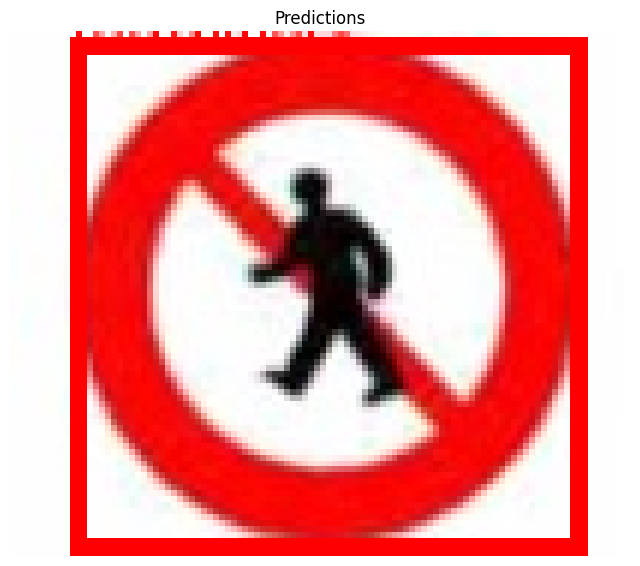

[{'x': 53.22425079345703,
  'y': 44.359129190444946,
  'width': 86.15223693847656,
  'height': 85.32931852340698,
  'confidence': 0.8643764853477478,
  'class': 'regulatory',
  'class_id': 4,
  'detection_id': '5d8459bb-b099-4b09-b693-f4e2dac6fd86'}]

In [52]:
# idx = 4
predictions = pipeline.detect(
    input_path / traffic_sign_descriptions[idx]["images"][0]
)
plot_prediction_boxes(
    image_path=input_path / traffic_sign_descriptions[idx]["images"][0],
    predictions=predictions
)
idx += 1
predictions